# Production SKU holdout backtest

30-day backtest for the current production-style setup: uplifted bakery forecast + normalized production SKU allocation from ClickHouse profiles. Actuals are raw `mart_sales_60d` quantities, matching the embedded app UI.

In [ ]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path('..').resolve()
OUT_DIR = ROOT / 'reports' / 'prod_holdout_sku_backtest'
COMPARE_PATH = OUT_DIR / 'prod_holdout_sku_compare.csv'
SUMMARY_PATH = OUT_DIR / 'summary.json'


with SUMMARY_PATH.open(encoding='utf-8') as f:
    summary = json.load(f)

df = pd.read_csv(COMPARE_PATH, parse_dates=['date'])
by_day = pd.read_csv(OUT_DIR / 'by_day.csv', parse_dates=['date'])
by_bakery = pd.read_csv(OUT_DIR / 'by_bakery.csv')
by_sku = pd.read_csv(OUT_DIR / 'by_bakery_sku.csv')
cell = pd.read_csv(OUT_DIR / 'cell_type_summary.csv')

summary

{'window': {'start': '2026-05-02', 'end': '2026-05-31'},
 'configuration': {'bakery_holdout_path': 'C:\\Users\\dns\\Desktop\\Projects\\demand-forecasting-model\\reports\\bakery_day_model_uplifted_holdout_predictions.csv',
  'scenario': 'uplifted bakery forecast + normalized production SKU allocation',
  'profile_table': 'sku_hour_share_profile_smoothed_embedded',
  'sales_table': 'mart_sales_60d',
  'fact_source_note': 'Raw mart_sales_60d actuals, matching embedded UI actual_qty.'},
 'paths': {'bakery_allocator_input': 'C:\\Users\\dns\\Desktop\\Projects\\demand-forecasting-model\\reports\\prod_holdout_sku_backtest\\bakery_holdout_uplifted_allocator_input.csv',
  'sku_day_forecast': 'C:\\Users\\dns\\Desktop\\Projects\\demand-forecasting-model\\data\\processed\\sku_day_forecast_holdout_30d_prod_uplifted_norm.csv',
  'sku_hour_forecast': 'C:\\Users\\dns\\Desktop\\Projects\\demand-forecasting-model\\data\\processed\\sku_hour_forecast_holdout_30d_prod_uplifted_norm.csv',
  'allocation_summa

## Allocation variants

These files are generated by `scripts/evaluate_sku_allocation_variants.py`. Variants preserve bakery-day forecast totals and change only SKU distribution.

In [2]:
VARIANT_DIR = ROOT / 'reports' / 'prod_holdout_sku_backtest_variants'
variant_summary = pd.read_csv(VARIANT_DIR / 'variant_summary.csv')
variant_summary

,variant,rows,fact_sum,forecast_sum,wmape_raw_fact_pct,wmape_scaled_fact_pct,bias_sum,dead_pair_forecast_qty,dead_pair_forecast_share_pct,forecast_only_fact_zero_qty,fact_only_forecast_zero_qty
0,baseline,909648,5266404.201,6.101000e+06,70.811390,64.833194,834595.832609,396099.344768,6.492368,688069.435187,283759.254
1,dead_0d,909648,5266404.201,6.101000e+06,66.149281,59.761480,834595.832609,42899.586312,0.703157,347798.030826,288081.571
2,active_3d,909648,5266404.201,6.101000e+06,66.059341,59.655891,834595.832609,37313.252987,0.611592,339816.672138,290933.754
3,blend_recent_50,909648,5266404.201,6.101000e+06,48.290467,42.586825,834595.832609,56322.502315,0.923168,322205.888501,33432.525
4,core_recent_70,909648,5266404.201,6.101000e+06,49.133722,43.118126,834595.832609,49798.450755,0.816234,320046.749797,33432.525


In [20]:
BAKERY_ID = 142
PRODUCT_ID = 1071

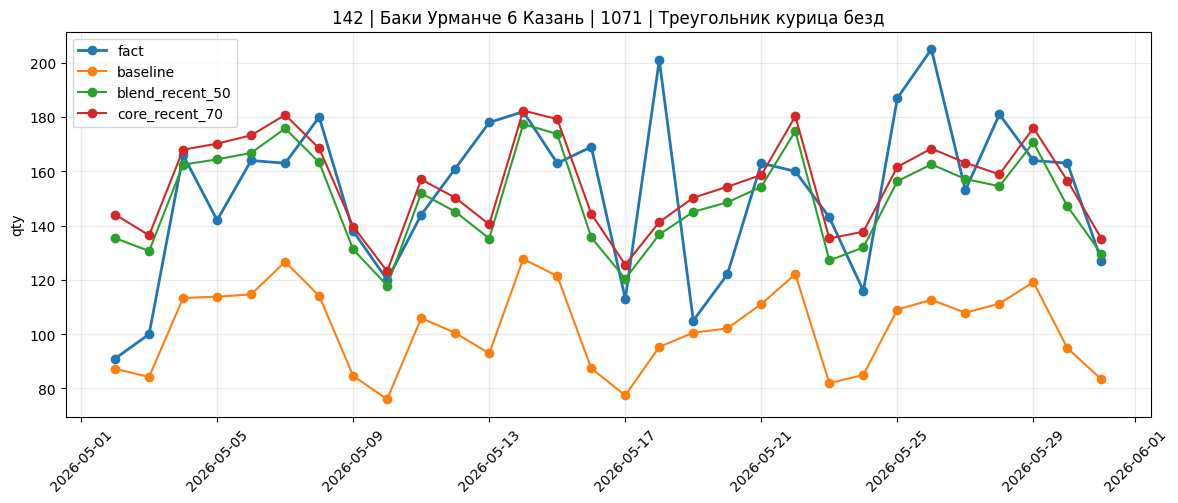

In [21]:
def plot_variant_pair(bakery_id: int, product_id: int, variants=('baseline', 'blend_recent_50', 'core_recent_70')):
    fig, ax = plt.subplots(figsize=(14, 5))
    first = True
    for variant in variants:
        part = pd.read_csv(VARIANT_DIR / f'{variant}_compare.csv', parse_dates=['date'])
        part = part[(part['bakery_id'] == bakery_id) & (part['product_id'] == product_id)].sort_values('date')
        if part.empty:
            continue
        if first:
            ax.plot(part['date'], part['fact_qty'], marker='o', linewidth=2, label='fact')
            title = f"{bakery_id} | {part['bakery_name'].iloc[0]} | {product_id} | {part['product_name'].iloc[0]}"
            first = False
        ax.plot(part['date'], part['forecast_variant'], marker='o', label=variant)
    ax.set_title(title if not first else 'No rows')
    ax.set_ylabel('qty')
    ax.grid(True, alpha=0.25)
    ax.legend()
    plt.xticks(rotation=45)
    plt.show()

plot_variant_pair(BAKERY_ID, PRODUCT_ID)

## Aggregate picture

`fact_qty` is the raw app fact. `fact_scaled_to_forecast_total` keeps the actual SKU mix but rescales each bakery-day to the forecast total, so it isolates allocation/share error from total bakery forecast error.

In [19]:
df[df['bakery_name'] == 'Баки Урманче 6 Казань']['bakery_id']

524849    142
524850    142
524851    142
524852    142
524853    142
         ... 
532509    142
532510    142
532511    142
532512    142
532513    142
Name: bakery_id, Length: 7665, dtype: int64

In [4]:
print('Rows:', len(df))
print('Date range:', df['date'].min().date(), '..', df['date'].max().date())
print('Bakeries:', df['bakery_id'].nunique())
print('Products:', df['product_id'].nunique())
print('Raw fact WMAPE:', summary['metrics_vs_raw_app_fact']['wmape_pct'])
print('Scaled fact WMAPE:', summary['metrics_vs_fact_scaled_to_forecast_total']['wmape_pct'])
print('Dead-pair forecast share:', summary['dead_pair_leakage']['forecast_share_pct'])
cell

Rows: 909648
Date range: 2026-05-02 .. 2026-05-31
Bakeries: 187
Products: 892
Raw fact WMAPE: 70.81138983420072
Scaled fact WMAPE: 64.83319376993437
Dead-pair forecast share: 6.4923675231227715


,cell_type,rows,fact_qty,forecast_qty,abs_err_raw_fact,abs_err_scaled_fact
0,both_positive,513462,4982644.947,5.412931e+06,2.757385e+06,2.931919e+06
1,fact_only_forecast_zero,120575,283759.254,0.000000e+00,2.837593e+05,3.299339e+05
2,forecast_only_fact_zero,275611,0.000,6.880694e+05,6.880694e+05,6.880694e+05


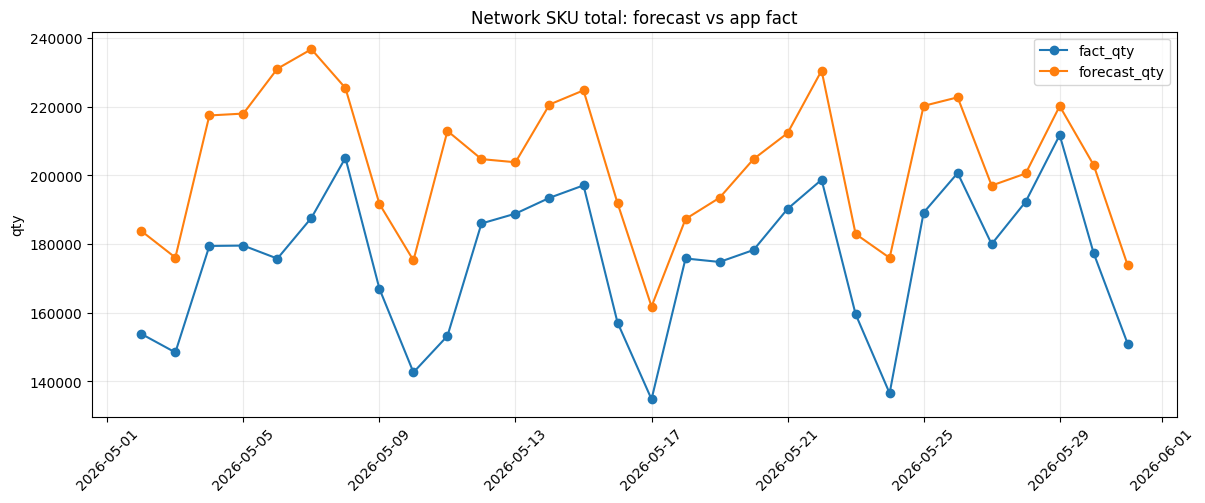

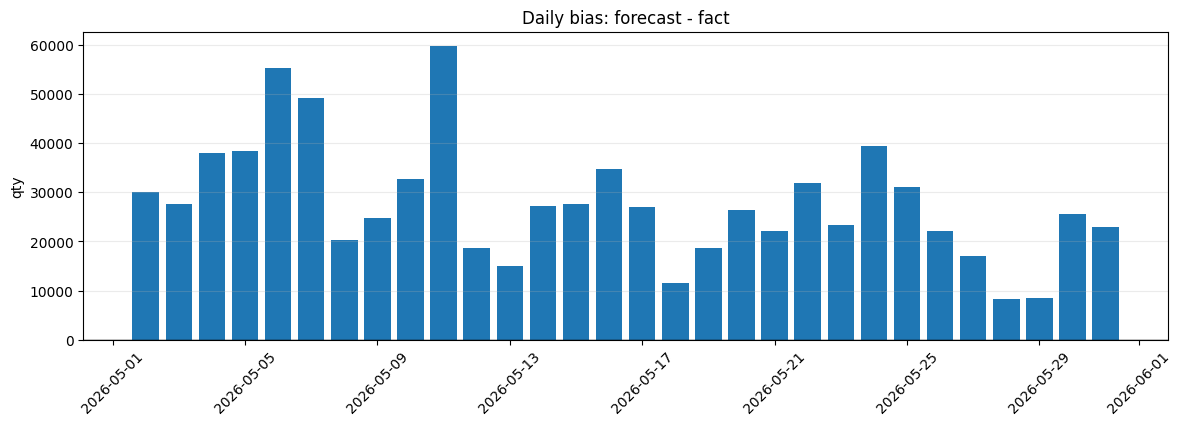

In [10]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(by_day['date'], by_day['fact_qty'], marker='o', label='fact_qty')
ax.plot(by_day['date'], by_day['forecast_qty'], marker='o', label='forecast_qty')
ax.set_title('Network SKU total: forecast vs app fact')
ax.set_ylabel('qty')
ax.grid(True, alpha=0.25)
ax.legend()
plt.xticks(rotation=45)
plt.show()

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(by_day['date'], by_day['forecast_qty'] - by_day['fact_qty'])
ax.axhline(0, color='black', linewidth=1)
ax.set_title('Daily bias: forecast - fact')
ax.set_ylabel('qty')
ax.grid(True, axis='y', alpha=0.25)
plt.xticks(rotation=45)
plt.show()

## Top problem pairs

The first table shows live SKU pairs with the strongest underforecast. The second table shows forecast sent to pairs with zero fact during the full 30-day window.

In [11]:
top_under = pd.read_csv(OUT_DIR / 'top_underforecast_bakery_sku.csv')
top_dead = pd.read_csv(OUT_DIR / 'top_dead_pair_forecast.csv')
display(top_under.head(30))
display(top_dead.head(30))

,bakery_id,bakery_name,city,product_id,product_name,category_name,fact_qty,fact_revenue,forecast_qty,abs_err_raw_fact,abs_err_scaled_fact,days_fact_positive,days_forecast_positive,bias_qty,wmape_raw_fact_pct,dead_pair_window
0,105,Фучика 96 Казань,Казань,1071,Треугольник курица безд,Выпечка сытная,6150.000,458148.00,2218.969957,3931.030043,3569.135028,30,30,-3931.030043,63.919188,False
1,11,Фучика 72 Казань,Казань,1071,Треугольник курица безд,Выпечка сытная,5424.000,398886.83,1587.503354,3836.496646,3459.914044,30,30,-3836.496646,70.731870,False
2,30,Баумана 29/11 Казань,Казань,1071,Треугольник курица безд,Выпечка сытная,5031.000,368063.00,1611.564569,3419.435431,3355.375296,30,30,-3419.435431,67.967311,False
3,18,Хади Такташ 105 Казань,Казань,1071,Треугольник курица безд,Выпечка сытная,4826.800,347446.00,1475.502549,3351.297451,3429.698585,30,30,-3351.297451,69.431040,False
4,79,Ильича 19/43 Казань,Казань,1071,Треугольник курица безд,Выпечка сытная,8224.000,605908.07,4939.280363,3284.719637,5012.631921,30,30,-3284.719637,39.940657,False
5,137,Татарстан 53А Казань,Казань,1071,Треугольник курица безд,Выпечка сытная,5581.000,413575.25,2340.961857,3240.038143,2891.706235,30,30,-3240.038143,58.054796,False
6,108,Чулман 9 Нижнекамск,Нижнекамск,1071,Треугольник курица безд,Выпечка сытная,4453.000,329729.00,1443.679268,3009.320732,2904.747855,30,30,-3009.320732,67.579626,False
7,29,Айдарова 8А корп 1 Казань,Казань,1071,Треугольник курица безд,Выпечка сытная,7525.000,561666.15,4566.641732,2958.358268,4385.432075,30,30,-2958.358268,39.313731,False
8,30,Баумана 29/11 Казань,Казань,1076,Треугольник говядина безд,Выпечка сытная,4005.000,337100.00,1247.561466,2757.438534,2667.226581,30,30,-2757.438534,68.849901,False
9,60,Мусина 68 Казань,Казань,1071,Треугольник курица безд,Выпечка сытная,4262.000,310366.00,1566.942303,2695.057697,2687.838934,30,30,-2695.057697,63.234578,False


,bakery_id,bakery_name,city,product_id,product_name,category_name,fact_qty,fact_revenue,forecast_qty,abs_err_raw_fact,abs_err_scaled_fact,days_fact_positive,days_forecast_positive,bias_qty,wmape_raw_fact_pct,dead_pair_window
0,86,Лемаева 2А Нижнекамск,Нижнекамск,10739,Булочка с яблоком,Выпечка сладкая,0.0,0.0,1819.552310,1819.552310,1819.552310,0,30,1819.552310,NaN,True
1,22,Сибирский Тракт 25 Казань,Казань,10739,Булочка с яблоком,Выпечка сладкая,0.0,0.0,1402.615929,1402.615929,1402.615929,0,30,1402.615929,NaN,True
2,30,Баумана 29/11 Казань,Казань,10739,Булочка с яблоком,Выпечка сладкая,0.0,0.0,1253.977916,1253.977916,1253.977916,0,30,1253.977916,NaN,True
3,231,Клыкова 92 Курск,Курск,70,Московская плюшка П,Хлеб,0.0,0.0,1167.836874,1167.836874,1167.836874,0,30,1167.836874,NaN,True
4,30,Баумана 29/11 Казань,Казань,10608,Перемяч,Выпечка сытная,0.0,0.0,1127.077369,1127.077369,1127.077369,0,30,1127.077369,NaN,True
5,30,Баумана 29/11 Казань,Казань,10740,Булочка с вишней,Выпечка сладкая,0.0,0.0,1041.199904,1041.199904,1041.199904,0,30,1041.199904,NaN,True
6,79,Ильича 19/43 Казань,Казань,10608,Перемяч,Выпечка сытная,0.0,0.0,1025.706532,1025.706532,1025.706532,0,30,1025.706532,NaN,True
7,22,Сибирский Тракт 25 Казань,Казань,10608,Перемяч,Выпечка сытная,0.0,0.0,1022.395822,1022.395822,1022.395822,0,30,1022.395822,NaN,True
8,79,Ильича 19/43 Казань,Казань,4944,Пирожок капуста и курица,Выпечка сытная,0.0,0.0,1004.911244,1004.911244,1004.911244,0,30,1004.911244,NaN,True
9,231,Клыкова 92 Курск,Курск,1025,Расстегай горбуша и рис мск,Выпечка сытная,0.0,0.0,999.778163,999.778163,999.778163,0,30,999.778163,NaN,True


## Inspect one bakery-SKU pair

Change `BAKERY_ID` and `PRODUCT_ID` and rerun the next cells. Defaults are a large underforecast example from the generated report.

In [ ]:
BAKERY_ID = 30
PRODUCT_ID = 1071

def plot_pair(bakery_id: int, product_id: int) -> pd.DataFrame:
    part = df[(df['bakery_id'] == bakery_id) & (df['product_id'] == product_id)].sort_values('date')
    if part.empty:
        print('No rows for pair')
        return part
    title = f"{bakery_id} | {part['bakery_name'].iloc[0]} | {product_id} | {part['product_name'].iloc[0]}"
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(part['date'], part['fact_qty'], marker='o', label='fact_qty')
    ax.plot(part['date'], part['forecast_qty'], marker='o', label='forecast_qty')
    ax.plot(part['date'], part['fact_scaled_to_forecast_total'], marker='o', linestyle='--', label='fact scaled to bakery forecast total')
    ax.set_title(title)
    ax.set_ylabel('qty')
    ax.grid(True, alpha=0.25)
    ax.legend()
    plt.xticks(rotation=45)
    plt.show()
    return part[[
        'date', 'fact_qty', 'forecast_qty', 'fact_scaled_to_forecast_total',
        'err_raw_fact', 'err_scaled_fact', 'forecast_share_in_bakery_day',
        'fact_share_in_bakery_day', 'share_delta', 'cell_type'
    ]]

plot_pair(BAKERY_ID, PRODUCT_ID)

## Inspect a bakery top SKU set

This plots top SKU by fact quantity for one bakery. It is useful for checking whether major live SKU consistently lose share while smaller/dead SKU receive forecast.

In [ ]:
def plot_bakery_top_sku(bakery_id: int, top_n: int = 10) -> pd.DataFrame:
    pairs = (
        by_sku[(by_sku['bakery_id'] == bakery_id) & (by_sku['fact_qty'] > 0)]
        .sort_values('fact_qty', ascending=False)
        .head(top_n)
    )
    if pairs.empty:
        print('No fact-positive SKU for bakery')
        return pairs
    fig, axes = plt.subplots(len(pairs), 1, figsize=(14, max(3, 2.2 * len(pairs))), sharex=True)
    if len(pairs) == 1:
        axes = [axes]
    for ax, row in zip(axes, pairs.itertuples(index=False)):
        part = df[(df['bakery_id'] == bakery_id) & (df['product_id'] == row.product_id)].sort_values('date')
        ax.plot(part['date'], part['fact_qty'], marker='o', label='fact')
        ax.plot(part['date'], part['forecast_qty'], marker='o', label='forecast')
        ax.set_title(f"{row.product_id} | {row.product_name} | bias={row.bias_qty:.0f}", fontsize=10)
        ax.grid(True, alpha=0.25)
    axes[0].legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    return pairs

plot_bakery_top_sku(BAKERY_ID, top_n=10)

## Bakery ranking

Use this to pick bakeries with the largest total bias or highest WMAPE, then feed their id into the previous plotting cells.

In [ ]:
display(by_bakery.sort_values('bias_qty').head(20))
display(by_bakery.sort_values('wmape_raw_fact_pct', ascending=False).head(20))